# Business Sales Performance Analytics

## Future Interns – Data Science & Analytics Task 1

### Objective

The goal of this project is to analyze retail sales data and identify key business insights related to revenue, profitability, product performance, category performance, and regional trends. The findings can help business stakeholders make data-driven decisions and improve overall business performance.

# Dataset Overview

The dataset contains sales transactions from a retail superstore business.

### Key Features:
- Order Information
- Customer Information
- Product Categories
- Sales Revenue
- Profit
- Region and State
- Shipping Details

This dataset enables analysis of business performance across multiple dimensions such as products, categories, regions, and time.


# Importing Required Libraries

The following libraries are used for data manipulation, analysis, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


In [7]:
import os

path = "/kaggle/input/datasets/vivek468/superstore-dataset-final"

print(os.listdir(path))

['Sample - Superstore.csv']


# Loading the Dataset

The dataset is loaded into a Pandas DataFrame for further analysis and processing.

In [8]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv',
    encoding='latin1'
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Initial Data Exploration

Understanding the structure of the dataset by examining:
- Number of rows and columns
- Available features
- Sample records

In [9]:
print(df.shape)

(9994, 21)


In [10]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [11]:
print(df.head)

<bound method NDFrame.head of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       C

In [12]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Data Cleaning

Data cleaning is performed to ensure accuracy and reliability of the analysis.

Steps:
- Checking missing values
- Identifying duplicate records
- Removing duplicates if present
- Validating data types

In [16]:
df.drop_duplicates(inplace=True)

In [18]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

# Feature Engineering

Additional time-based features such as Year and Month are extracted from the Order Date column to support trend analysis.

In [19]:
df[['Order Date','Year','Month']].head()

,Order Date,Year,Month
0,2016-11-08,2016,November
1,2016-11-08,2016,November
2,2016-06-12,2016,June
3,2015-10-11,2015,October
4,2015-10-11,2015,October


In [20]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Orders: 5009


In [21]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


# Top Products Analysis

This analysis identifies the products generating the highest sales revenue.

Understanding top-performing products helps businesses:
- Prioritize inventory
- Optimize marketing efforts
- Improve product strategy

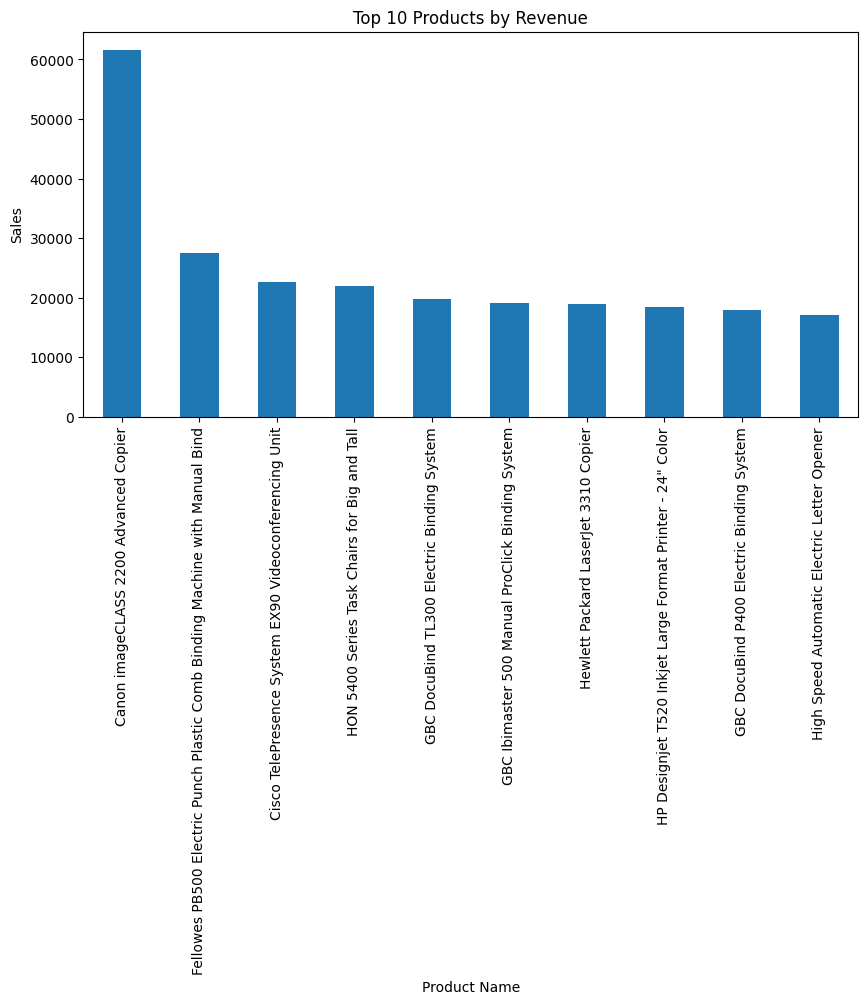

In [22]:
import matplotlib.pyplot as plt

top_products.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Products by Revenue")
plt.ylabel("Sales")
plt.show()

In [23]:
category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


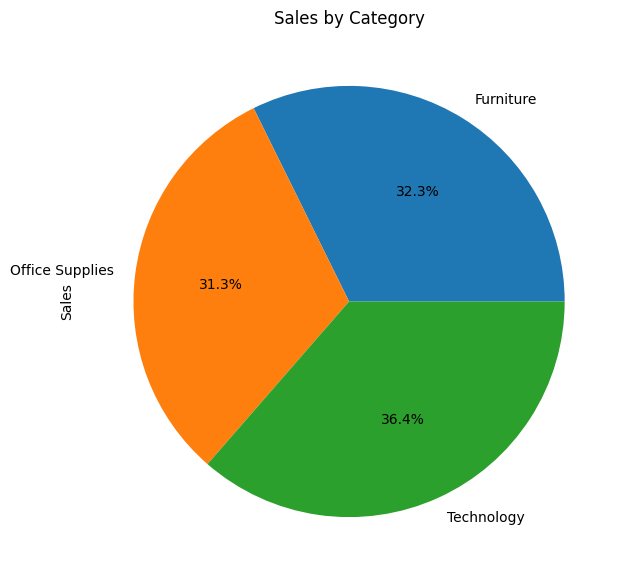

In [24]:
category_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Sales by Category")
plt.show()

In [25]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


# Regional Performance Analysis

Regional analysis helps identify high-performing and low-performing markets.

The results can support:
- Regional expansion strategies
- Marketing decisions
- Resource allocation

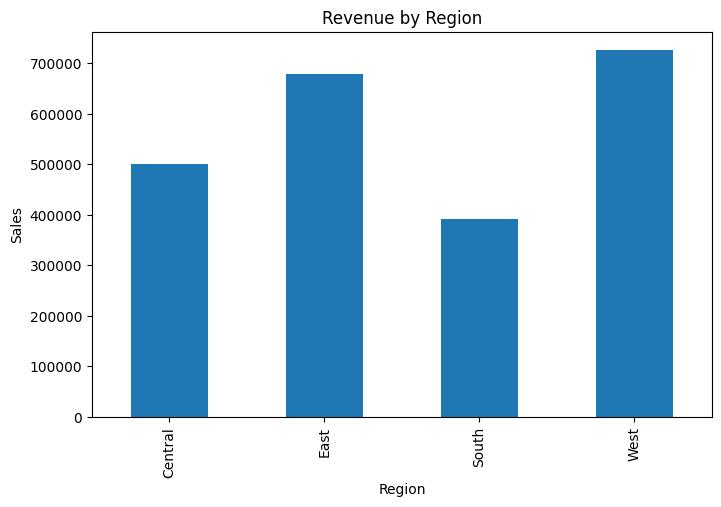

In [26]:
region_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Revenue by Region")
plt.ylabel("Sales")
plt.show()

# Revenue Trend Analysis

Analyzing revenue over time helps understand business growth patterns and seasonal fluctuations.

The trend analysis focuses on monthly sales performance across the available time period.

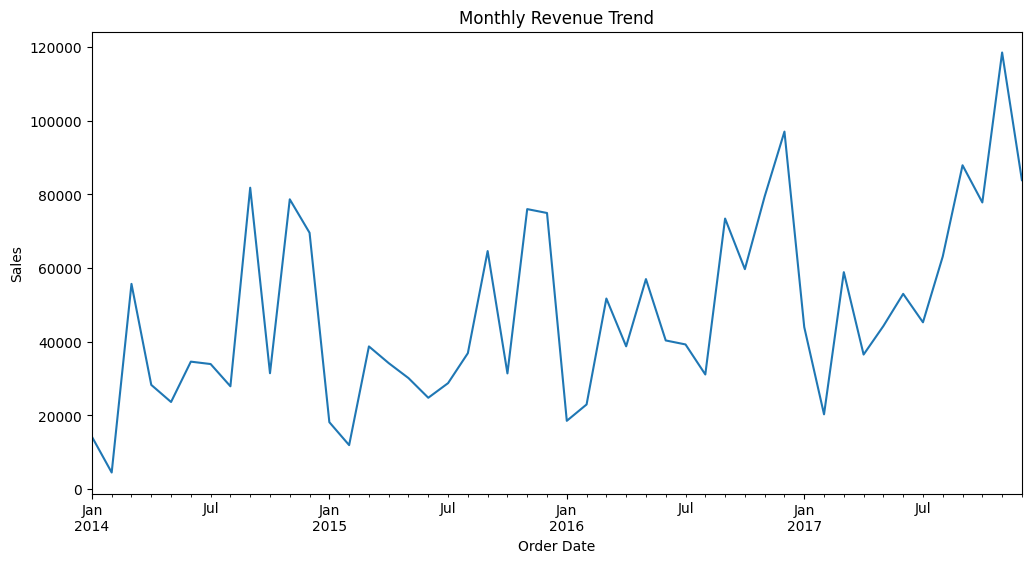

In [27]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.plot(figsize=(12,6))

plt.title("Monthly Revenue Trend")
plt.ylabel("Sales")
plt.show()

# Profitability Analysis

Revenue alone does not determine business success.

This section evaluates profitability across product categories to identify the most financially beneficial business segments.

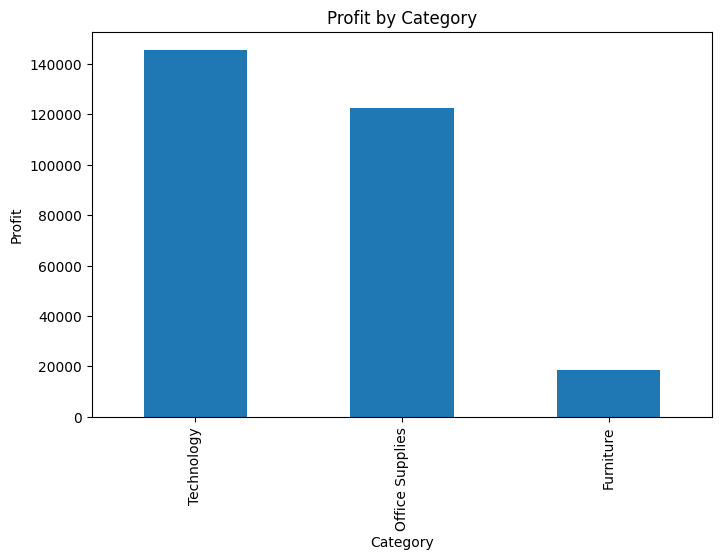

In [28]:
profit_by_category = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)

profit_by_category.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

In [29]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month'],
      dtype='object')


In [30]:
print(df.shape)

(9994, 23)


# Key Performance Indicators (KPIs)

This section calculates the most important business metrics:

- Total Sales Revenue
- Total Profit
- Total Orders
- Average Order Value

These KPIs provide a high-level overview of business performance.

In [31]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = total_sales / total_orders

print("Total Sales: $", round(total_sales,2))
print("Total Profit: $", round(total_profit,2))
print("Total Orders:", total_orders)
print("Average Order Value: $", round(avg_order_value,2))

Total Sales: $ 2297200.86
Total Profit: $ 286397.02
Total Orders: 5009
Average Order Value: $ 458.61


# Customer Segment Analysis

Customers are grouped into different segments.

This analysis helps determine which customer segments generate the highest revenue and contribute most to business growth.

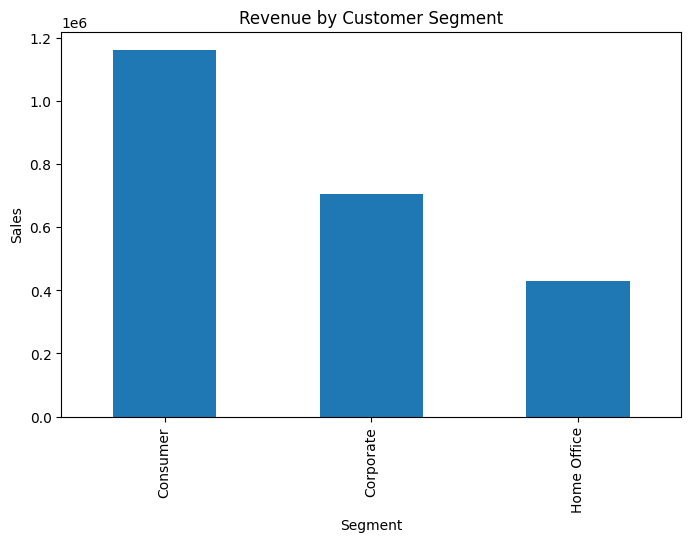

In [32]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Revenue by Customer Segment')
plt.ylabel('Sales')
plt.show()

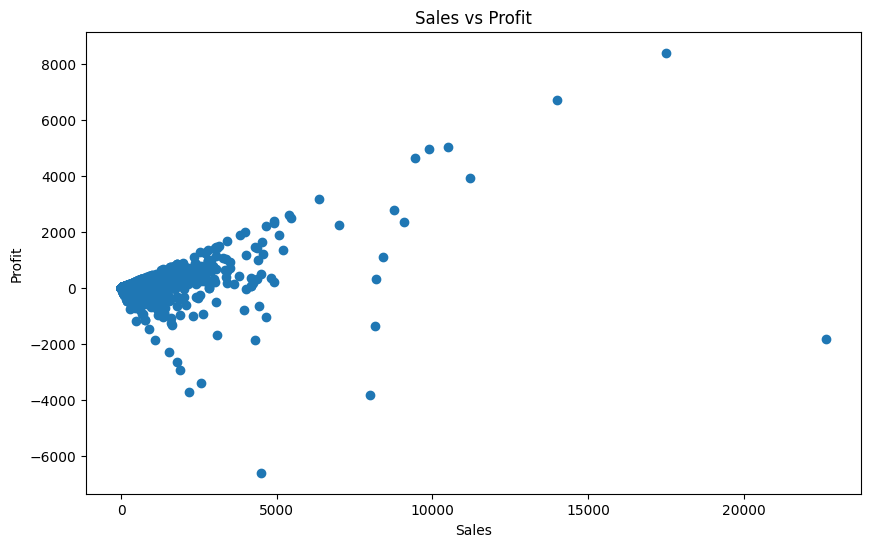

In [33]:
plt.figure(figsize=(10,6))

plt.scatter(df['Sales'], df['Profit'])

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.show()

# Key Business Insights

### Insight 1
Technology products generate the highest sales and profit.

### Insight 2
The West region contributes the highest revenue.

### Insight 3
The South region generates the lowest revenue.

### Insight 4
Sales show an overall upward trend from 2014 to 2017.

### Insight 5
A small number of products contribute a significant portion of total revenue.

# Recommendations

1. Increase investment in Technology products due to strong revenue and profitability.

2. Replicate successful sales strategies from the West region in other regions.

3. Develop targeted promotional campaigns in the South region.

4. Focus inventory planning on high-performing products.

5. Continue monitoring sales trends to support future growth strategies.

# Conclusion

This project successfully analyzed retail sales data to identify key trends, profitable categories, top-performing products, and regional performance differences.

The analysis demonstrates how data analytics can support strategic business decisions and improve operational efficiency.

Tools Used:
- Python
- Pandas
- Matplotlib
- Kaggle Notebook
- Power BI